# Chapter 20 Lab — Contrasts and Inference with the GLM (Python)

In the Chapter 18 lab you fit a two-condition GLM and tested a single contrast. This lab develops the full contrast machinery on a **three-condition** design — the kind of design where contrasts start doing real scientific work. The arc:

1. **Fit a three-condition GLM** to a simulated voxel with known ground truth
2. **Build and test t-contrasts**: single conditions, pairwise differences, and averages
3. **Scaling and centering**: what changes the numbers, and what changes only their *interpretation*
4. **F-contrasts**: testing several effects jointly with a contrast matrix
5. **Conjunction logic**: asking "A *and* B" questions rather than "A *or* B" questions

Because the data are simulated, every contrast has a known true value, so you can see exactly what each test does and does not detect.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `scipy`, `pandas`, and `matplotlib`, and all data are simulated — nothing to download. It accompanies the [chapter page](../ch20-contrasts-and-inference-with-the.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.6 | pandas 3.0.5


## Step 1 — A three-condition design

Imagine an experiment with three event types: **A** = famous faces, **B** = non-famous faces, and **C** = houses. Each condition gets one column in the design matrix, built exactly as in Chapter 18: an indicator (stimulus) function convolved with the canonical double-gamma HRF and sampled at the TR, plus an intercept as the last column.

We present 42 events (14 per condition) in a 400-second run, in a randomly interleaved order.

In [2]:
def canonical_hrf(t):
    # Double-gamma canonical HRF (SPM-style parameters), peak-normalized
    h = stats.gamma.pdf(t, 6, scale=1) - stats.gamma.pdf(t, 16, scale=1) / 6
    return h / h.max()

t_r, n_scans = 2.0, 200                     # TR = 2 s, 200 volumes (400 s)
run_len = n_scans * t_r
frame_times = np.arange(n_scans) * t_r
dt = 0.1                                    # fine grid for convolution
t_hi = np.arange(0, run_len, dt)
hrf = canonical_hrf(np.arange(0, 32, dt))

rng = np.random.default_rng(2024)

# 42 events spaced 9 s apart; randomly assign 14 each to A, B, C
conditions = ["A", "B", "C"]
all_onsets = np.arange(10, 385, 9.0)
labels = rng.permutation(np.repeat(conditions, 14))
onsets = {c: all_onsets[labels == c] for c in conditions}
duration = 1.0                              # each event lasts 1 s

def make_regressor(ons):
    stim = np.zeros_like(t_hi)
    for onset in ons:
        stim[(t_hi >= onset) & (t_hi < onset + duration)] = 1.0
    reg = np.convolve(stim, hrf)[: len(t_hi)]      # LTI prediction
    return reg / reg.max()                         # peak-normalize to 1

idx = np.round(frame_times / dt).astype(int)
X = np.column_stack([make_regressor(onsets[c])[idx] for c in conditions]
                    + [np.ones(n_scans)])
col_names = ["A", "B", "C", "constant"]
print("Design matrix shape (n x p):", X.shape)
print("\nTask regressor correlations:")
print(pd.DataFrame(np.corrcoef(X[:, :3].T),
                   index=conditions, columns=conditions).round(2))

Design matrix shape (n x p): (200, 4)

Task regressor correlations:
      A     B     C
A  1.00 -0.38 -0.37
B -0.38  1.00 -0.34
C -0.37 -0.34  1.00


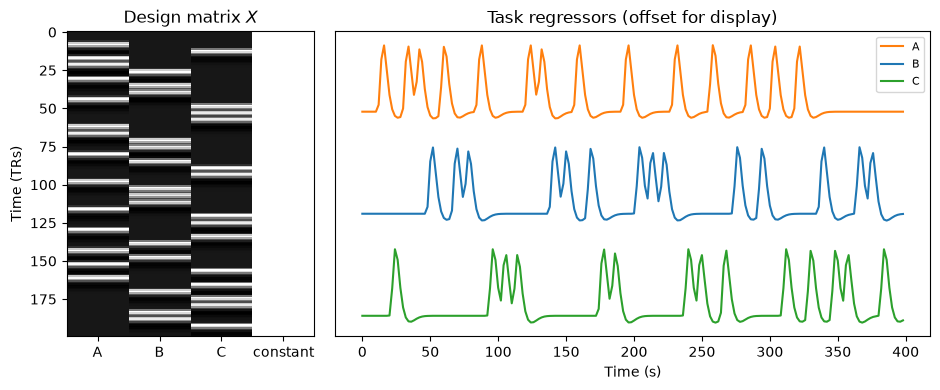

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4),
                         gridspec_kw={"width_ratios": [1, 2.4]})

axes[0].imshow(X / np.abs(X).max(0), aspect="auto", cmap="gray",
               interpolation="nearest")
axes[0].set(xticks=range(4), xticklabels=col_names,
            ylabel="Time (TRs)", title="Design matrix $X$")

for i, (c, color) in enumerate(zip(conditions,
                                   ["tab:orange", "tab:blue", "tab:green"])):
    axes[1].plot(frame_times, X[:, i] + 1.5 * (2 - i), color=color, label=c)
axes[1].set(xlabel="Time (s)", yticks=[], title="Task regressors (offset for display)")
axes[1].legend(loc="upper right", fontsize=8)
plt.tight_layout()

### Simulate a voxel and fit the GLM

We simulate a voxel that responds most to famous faces, somewhat to non-famous faces, and weakly to houses:

$$\beta_A = 1.0, \quad \beta_B = 0.6, \quad \beta_C = 0.3, \quad \beta_0 = 100$$

Because each task regressor is peak-normalized to 1 and the intercept is 100, a beta of $1.0$ corresponds to roughly a **1% signal change** — the units most fMRI papers report.

We fit by ordinary least squares, $\hat{\beta} = (X^TX)^{-1}X^Ty$, saving the pieces every contrast test will reuse: the residual variance $\hat{\sigma}^2$, the error degrees of freedom $df_e = n - p$, and $(X^TX)^{-1}$.

In [4]:
beta_true = np.array([1.0, 0.6, 0.3, 100.0])   # [A, B, C, intercept]
# Regressors peak at 1 and the intercept is 100, so a beta of 1.0 means a
# 1% signal change; noise SD is 0.15% of baseline.
sigma_noise = 0.15

y = X @ beta_true + sigma_noise * rng.standard_normal(n_scans)

# OLS fit (solve() is more stable than explicitly inverting X'X)
beta_hat = np.linalg.solve(X.T @ X, X.T @ y)

resid = y - X @ beta_hat
n, p = X.shape
dfe = n - p                                     # error degrees of freedom
sigma2_hat = resid @ resid / dfe                # error variance estimate
XtX_inv = np.linalg.inv(X.T @ X)

print(f"dfe = {dfe}, sigma2_hat = {sigma2_hat:.4f} (true {sigma_noise**2:.4f})")
pd.DataFrame({"true beta": beta_true, "estimated beta": beta_hat},
             index=col_names).round(3)

dfe = 196, sigma2_hat = 0.0220 (true 0.0225)


,true beta,estimated beta
A,1.0,1.031
B,0.6,0.585
C,0.3,0.318
constant,100.0,99.988


The betas land near their true values. But betas are rarely the final answer — the scientific questions live in *comparisons* among them.

## Step 2 — t-contrasts: one question, one number

A **contrast** is a linear combination of parameters, $c^T\beta$, chosen so that one scientific question becomes one number. Its estimate is $c^T\hat{\beta}$, its variance is

$$\mathrm{Var}(c^T\hat{\beta}) = \sigma^2\, c^T (X^TX)^{-1} c,$$

and its t-statistic is

$$t = \frac{c^T\hat{\beta}}{\sqrt{\hat{\sigma}^2\, c^T (X^TX)^{-1} c}}, \qquad df = df_e .$$

Two rules of thumb:

- **Comparisons between conditions** should use weights that **sum to zero** (e.g., $[1, -1, 0]$), so that $c^T\beta = 0$ under the null hypothesis of equal responses.
- **Tests against baseline** need not sum to zero (e.g., $[1, 0, 0]$ or $[\tfrac13, \tfrac13, \tfrac13]$): each $\beta$ is already 0 under the null, so any average of them is too. "Baseline" here means whatever was left unmodeled — the intercept.

Let's wrap the formula in a function and ask five questions of the same fitted model.

In [5]:
def t_contrast(c, name=""):
    c = np.asarray(c, float)
    value = c @ beta_hat
    se = np.sqrt(sigma2_hat * c @ XtX_inv @ c)
    t = value / se
    return {"contrast": name, "weights [A B C]": np.array2string(c[:3]),
            "true": c @ beta_true, "estimate": value, "SE": se,
            "t": t, "p": 2 * stats.t.sf(abs(t), dfe)}

tests = [
    t_contrast([1, 0, 0, 0],         "A vs. baseline"),
    t_contrast([0, 0, 1, 0],         "C vs. baseline"),
    t_contrast([1, -1, 0, 0],        "A - B (famous - nonfamous)"),
    t_contrast([0.5, 0.5, -1, 0],    "faces - houses"),
    t_contrast([1/3, 1/3, 1/3, 0],   "task average vs. baseline"),
]
pd.DataFrame(tests).set_index("contrast").round(4)

,weights [A B C],true,estimate,SE,t,p
contrast,,,,,,
A vs. baseline,[1. 0. 0.],1.0000,1.0311,0.0426,24.1934,0.0
C vs. baseline,[0. 0. 1.],0.3000,0.3180,0.0430,7.3997,0.0
A - B (famous - nonfamous),[ 1. -1. 0.],0.4000,0.4457,0.0390,11.4253,0.0
faces - houses,[ 0.5 0.5 -1. ],0.5000,0.4903,0.0345,14.2313,0.0
task average vs. baseline,[0.333 0.333 0.333],0.6333,0.6448,0.0364,17.7304,0.0


Read the table against the ground truth ($\beta_A = 1.0$, $\beta_B = 0.6$, $\beta_C = 0.3$):

- Every single-condition and average contrast is strongly positive — this voxel responds to *everything* relative to baseline.
- **faces − houses** uses $[0.5, 0.5, -1]$: the positive weights average the two face conditions so the estimate is a difference of *means*, in the same units as the betas (true value $0.8 - 0.3 = 0.5$).
- **A − B** has a smaller t than **A vs. baseline** even though their SEs are similar: its true effect (0.4) is simply smaller. Notice that the difference contrast's SE is not larger than the single-condition SEs here — how precisely a design estimates a *particular* contrast depends on the timing and correlation structure of the regressors (that is design efficiency, Chapter 27).

The same contrast machinery, applied at every voxel, produces the **contrast images** (COPEs) that carry single-subject effects up to group analysis.

## Step 3 — Scaling and centering: interpretation, not inference

**Scaling contrast weights does not change inference.** Multiplying $c$ by any constant scales the estimate *and* its standard error by the same factor, so t and P are untouched.

In [6]:
for c, name in [([1, -1, 0, 0], "c = [1 -1 0]"),
                ([4, -4, 0, 0], "c = [4 -4 0]")]:
    r = t_contrast(c, name)
    print(f"{name}:  estimate = {r['estimate']:+.3f},  "
          f"t = {r['t']:.3f},  p = {r['p']:.4f}")

c = [1 -1 0]:  estimate = +0.446,  t = 11.425,  p = 0.0000
c = [4 -4 0]:  estimate = +1.783,  t = 11.425,  p = 0.0000


Same t, same p — only the units of the estimate change. Two practical exceptions make the scale worth caring about anyway:

1. **Interpretable units.** If you analyze data scaled to percent signal change and want to *report* contrast values, scale weights so positive weights sum to $+1$ and negative weights to $-1$ (e.g., $[0.5, 0.5, -1]$, not $[1, 1, -2]$). Then the contrast is a difference between condition *means*.
2. **Consistency across participants.** Contrast scale must be identical for every subject entering a group analysis. If a participant is missing a run, re-normalize their weights so positives and negatives still sum to $\pm 1$ — otherwise scale differences masquerade as noise (or worse, signal) at the group level.

**Centering a covariate changes the intercept's meaning — nothing else.** Suppose we add a continuous covariate $w$ (say, a physiological arousal measure with mean around 3) to the model. Compare fits with raw $w$ versus mean-centered $w$:

In [7]:
w = 3.0 + rng.standard_normal(n_scans)        # covariate with nonzero mean
y_w = y + 0.5 * w                              # data with a true covariate effect

Xw_raw = np.column_stack([X[:, :3], w, np.ones(n_scans)])
Xw_cen = np.column_stack([X[:, :3], w - w.mean(), np.ones(n_scans)])

b_raw = np.linalg.solve(Xw_raw.T @ Xw_raw, Xw_raw.T @ y_w)
b_cen = np.linalg.solve(Xw_cen.T @ Xw_cen, Xw_cen.T @ y_w)

pd.DataFrame({"uncentered w": b_raw, "centered w": b_cen},
             index=["A", "B", "C", "w (slope)", "intercept"]).round(3)

,uncentered w,centered w
A,1.027,1.027
B,0.579,0.579
C,0.312,0.312
w (slope),0.489,0.489
intercept,100.024,101.499


The task betas and the covariate slope are **identical** in both fits — so every contrast among them is identical too. Only the intercept moves: with raw $w$ it estimates the expected signal when $w = 0$ (an extrapolation that may be meaningless), while with centered $w$ it estimates the signal at the *average* covariate value. Centering is about making parameters interpretable, not about changing the model's fit. The same logic explains why "activation vs. baseline" contrasts always mean "relative to whatever the intercept absorbs."

## Step 4 — F-contrasts: testing several effects jointly

A t-contrast tests one linear combination — one degree of freedom, signed. An **F-contrast** tests whether a *set* of contrasts is jointly nonzero. Stack the contrasts as rows of a matrix $L$ (each row one contrast, $q$ rows total); then

$$F = \frac{(L\hat{\beta})^T \left[L (X^TX)^{-1} L^T\right]^{-1} (L\hat{\beta})}{q\, \hat{\sigma}^2}
 \;\sim\; F_{q,\; df_e} \text{ under } H_0 .$$

Equivalently, F compares the **full model** with a **reduced model** that omits the tested subspace:

$$F = \frac{(r_0^T r_0 - r^T r)/\nu_1}{r^T r / \nu_2},$$

where $r_0$ and $r$ are reduced- and full-model residuals — "how much *extra* variance do the effects of interest explain?" Typical uses: testing a block of nuisance covariates jointly, an omnibus any-effect test, or testing condition differences across multiple HRF basis functions (whose betas are *incommensurate* and cannot simply be averaged).

F-tests are **unsigned and non-directional**: positive and negative deviations both increase F.

In [8]:
def f_contrast(rows):
    L = np.atleast_2d(np.asarray(rows, float))   # one contrast per row
    q = L.shape[0]
    Lb = L @ beta_hat
    F = Lb @ np.linalg.solve(L @ XtX_inv @ L.T, Lb) / (q * sigma2_hat)
    return F, q, stats.f.sf(F, q, dfe)

# 1) Omnibus: does the task explain ANY variance (A, B, C jointly)?
F_any, q, p_any = f_contrast([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0]])
print(f"Any task effect:          F({q},{dfe}) = {F_any:7.2f}, p = {p_any:.3g}")

# ... which equals the full-vs-reduced-model computation (reduced = intercept only)
X0 = np.ones((n_scans, 1))
r0 = y - X0 @ np.linalg.solve(X0.T @ X0, X0.T @ y)
rss0, rss = r0 @ r0, resid @ resid
F_rss = ((rss0 - rss) / 3) / (rss / dfe)
print(f"Full vs. reduced (RSS):   F(3,{dfe}) = {F_rss:7.2f}   <- identical")

# 2) Do the conditions differ from EACH OTHER at all? (one-way ANOVA omnibus)
F_diff, q, p_diff = f_contrast([[1, -1, 0, 0], [0, 1, -1, 0]])
print(f"Any condition difference: F({q},{dfe}) = {F_diff:7.2f}, p = {p_diff:.3g}")

# 3) An F-test of a single contrast is just the square of its t-test
F_ab, _, _ = f_contrast([1, -1, 0, 0])
t_ab = t_contrast([1, -1, 0, 0])["t"]
print(f"F(A-B) = {F_ab:.3f}  =  t(A-B)^2 = {t_ab ** 2:.3f}")

Any task effect:          F(3,196) =  219.15, p = 2.4e-62
Full vs. reduced (RSS):   F(3,196) =  219.15   <- identical
Any condition difference: F(2,196) =  170.76, p = 1.16e-43
F(A-B) = 130.538  =  t(A-B)^2 = 130.538


Three things to notice:

- The **any-task-effect** F is enormous — unsurprising, since all three conditions activate this voxel strongly relative to baseline. The contrast-matrix formula and the full-vs-reduced RSS computation agree exactly: they are the same test.
- The **any-condition-difference** F spans just two rows ($A-B$ and $B-C$), yet those two rows span *all* pairwise differences — including $A-C$, which is their sum. It ignores the (huge) shared activation vs. baseline and asks only whether the conditions differ from each other.
- A one-row F-contrast reproduces the two-tailed t-test, with $F = t^2$ — but it discards the sign.

## Step 5 — Conjunction: "A and B", not "A or B"

An F-test asks whether *any* combination of the tested effects is nonzero — a logical **OR** (and an unsigned one). Many scientific claims are logical **AND** claims: for instance, "this region responds to faces *whether or not* they are famous" requires **both** $A - C > 0$ **and** $B - C > 0$.

The simple, valid way to test the AND claim (the *conjunction null*) is the **minimum-statistic** rule: declare a conjunction only if **every** component contrast individually exceeds the significance threshold — equivalently, if $\min(t_1, t_2) > t_{crit}$. Beware the common fallacy of concluding "both effects present" from a significant F or from one significant test plus one non-significant test.

We simulate two new voxels with the same design:

- **Voxel 1** responds to both face types ($\beta = [0.9, 0.8, 0.1]$) — a genuinely face-selective region
- **Voxel 2** responds only to famous faces ($\beta = [0.9, 0.1, 0.1]$)

In [9]:
def voxel_contrast_tests(beta_v, label):
    y_v = X @ beta_v + sigma_noise * rng.standard_normal(n_scans)
    b = np.linalg.solve(X.T @ X, X.T @ y_v)
    r = y_v - X @ b
    s2 = r @ r / dfe
    out = {"voxel": label}
    for name, c in [("A-C", [1, 0, -1, 0]), ("B-C", [0, 1, -1, 0])]:
        c = np.asarray(c, float)
        out[f"t({name})"] = c @ b / np.sqrt(s2 * c @ XtX_inv @ c)
    out["min t"] = min(out["t(A-C)"], out["t(B-C)"])
    return out

t_crit = stats.t.ppf(0.95, dfe)                # one-sided, alpha = .05
print(f"t_crit (one-sided, alpha = .05, df = {dfe}) = {t_crit:.2f}\n")

conj = pd.DataFrame([
    voxel_contrast_tests(np.array([0.9, 0.8, 0.1, 100.0]), "1: A and B > houses"),
    voxel_contrast_tests(np.array([0.9, 0.1, 0.1, 100.0]), "2: only A > houses"),
]).set_index("voxel")
conj["conjunction?"] = conj["min t"] > t_crit
conj.round(2)

t_crit (one-sided, alpha = .05, df = 196) = 1.65



,t(A-C),t(B-C),min t,conjunction?
voxel,,,,
1: A and B > houses,19.80,17.38,17.38,True
2: only A > houses,19.08,-0.22,-0.22,False


Voxel 1 passes the conjunction — both contrasts clear the threshold on their own, so we can claim the region responds to famous **and** non-famous faces more than houses. Voxel 2 shows a strong famous-face effect, but its $t(B{-}C)$ hovers near zero, the minimum statistic fails, and the AND claim is (correctly) rejected — even though an F-test over the same two contrasts would light up brightly for this voxel. Choosing between F (any effect) and conjunction (all effects) is choosing which logical question you are asking.

## Where to go next

- **Chapter 21:** contrast images computed here become the inputs to group-level (second-level) analysis
- **Chapter 22:** running these tests at ~100,000 voxels demands multiple-comparisons correction
- **Chapter 19:** with real fMRI noise, replace $\hat{\sigma}^2 (X^TX)^{-1}$ with its GLS/prewhitened counterpart — the contrast logic is unchanged

**Exercises**

1. Test the contrast $[1, -0.5, -0.5, 0]$ ("famous faces vs. the average of everything else"). What is its true value under our simulation? Verify your prediction.
2. The weights $[2, -1, -1, 0]$ and $[1, -0.5, -0.5, 0]$ test the same hypothesis. Confirm the t-values match, then state which scaling you would report for percent-signal-change data and why.
3. Build the 2×2 factorial from the chapter (conditions A–D) by splitting each of our three conditions differently: simulate four conditions with betas $[1.0, 0.8, 0.5, 0.7]$ and test the two main effects and the interaction using $[1, 1, -1, -1]$, $[1, -1, 1, -1]$, and $[1, -1, -1, 1]$ (each with a 0 for the intercept). Which effects are detectable?
4. In the conjunction demo, gradually raise voxel 2's $\beta_B$ from 0.1 toward 0.8 (re-running the simulation several times per value). Around what effect size does the conjunction start to succeed reliably? What does this tell you about the power cost of AND claims?